# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
# Importing the basic libraries we will require for the project

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Importing the Machine Learning models we require from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# Importing the other functions we may require from Scikit-Learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# To get diferent metric scores
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,precision_recall_curve,roc_curve,make_scorer

# Code to ignore warnings from function usage
import warnings;
import numpy as np
warnings.filterwarnings('ignore')

## Data Overview

- Observations
- Sanity checks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ML and AI /Classification and Hypothesis Testing/Project 2/ExtraaLearn.csv')

In [ ]:
df.shape

(4612, 15)

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

# Get information about the DataFrame
display(df.info())

# Get descriptive statistics of the DataFrame
display(df.describe())

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

None

,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.000000,4612.000000,4612.000000,4612.000000,4612.000000
mean,46.201214,3.566782,724.011275,3.026126,0.298569
std,13.161454,2.829134,743.828683,1.968125,0.457680
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,148.750000,2.077750,0.000000
50%,51.000000,3.000000,376.000000,2.792000,0.000000
75%,57.000000,5.000000,1336.750000,3.756250,1.000000
max,63.000000,30.000000,2537.000000,18.434000,1.000000


### Observations:

The dataset contains 4612 entries and 15 columns.

There are no missing values in any of the columns, which simplifies the preprocessing steps.

The columns include a mix of data types: object (categorical/string), int64 (integer), and float64 (decimal).

The numerical columns (age, website_visits, time_spent_on_website, page_views_per_visit, status) have a wide range of values, as seen in the describe() output.

The status column, which is the target variable, is an integer type (0 or 1), indicating whether a lead was converted or not.

Several columns are of object type, which will need to be handled during data preprocessing for model building (e.g., current_occupation, first_interaction, profile_completed, last_activity, and the media/referral flags).

The ID column is likely a unique identifier and may not be useful for the model.

Looking at the `describe()` output for numerical columns:

*   **Age:** The average age is around 46 years, with a standard deviation of about 13. This indicates a relatively wide distribution of ages among the leads. The minimum age is 18 and the maximum is 63.
*   **Website Visits:** On average, leads visit the website about 3.6 times. The minimum is 0 visits and the maximum is 30, suggesting some leads are very active visitors while many visit infrequently.
*   **Time Spent on Website:** The average time spent on the website is around 724 seconds (about 12 minutes). The values range from 0 to 2537 seconds, indicating a large variation in how long leads engage with the website.
*   **Page Views Per Visit:** The average number of page views per visit is about 3.0. The values range from 0 to 18.4, again showing a wide range of engagement levels during each visit.
*   **Status:** The mean of the status column is 0.298, which confirms that approximately 29.8% of the leads were converted (since 1 represents converted and 0 represents not converted). This is consistent with the `value_counts` we observed earlier.

These descriptive statistics give us a quantitative summary of the central tendency, spread, and range of the numerical features.

In [ ]:
# List of all important categorical variables
cat_col = ["current_occupation", "first_interaction", 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']

# Printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

current_occupation
Professional    0.567216
Unemployed      0.312446
Student         0.120338
Name: proportion, dtype: float64
--------------------------------------------------
first_interaction
Website       0.551171
Mobile App    0.448829
Name: proportion, dtype: float64
--------------------------------------------------
profile_completed
High      0.490893
Medium    0.485906
Low       0.023200
Name: proportion, dtype: float64
--------------------------------------------------
last_activity
Email Activity      0.493929
Phone Activity      0.267563
Website Activity    0.238508
Name: proportion, dtype: float64
--------------------------------------------------
print_media_type1
No     0.892238
Yes    0.107762
Name: proportion, dtype: float64
--------------------------------------------------
print_media_type2
No     0.94948
Yes    0.05052
Name: proportion, dtype: float64
--------------------------------------------------
digital_media
No     0.885733
Yes    0.114267
Name: proportion, 

### Observations:  

current_occupation: About 56.7% of the leads are Professionals, 31.2% are Unemployed, and 12% are Students. This shows that professionals form the largest group in your dataset.

first_interaction: The initial interaction is split relatively evenly, with about 55.1% of leads coming through the Website and 44.9% through the Mobile App.

profile_completed: Almost half of the leads (around 49.1%) have a High profile completion, another large portion (around 48.6%) have Medium completion, and a very small percentage (only 2.3%) have Low completion. This suggests that most leads engage enough to complete at least a medium level of their profile.

last_activity: Email Activity is the most common last activity (around 49.4%), followed by Phone Activity (around 26.8%), and then Website Activity (around 23.9%).

print_media_type1: A large majority of leads (around 89.2%) did not interact through Print Media Type 1, while about 10.8% did.

print_media_type2: Similarly, an even larger majority (around 94.9%) did not interact through Print Media Type 2, with only about 5.1% doing so. Both print media types seem to be less common interaction channels compared to others.

digital_media: Around 88.6% of leads did not interact through Digital Media, while about 11.4% did. This channel has a slightly higher proportion of interaction compared to the print media types.

educational_channels: About 84.7% of leads did not interact through Educational Channels, while about 15.3% did. This channel appears to be a more significant source of interaction than print or digital media.

referral: A vast majority of leads (around 98%) did not come through a referral, with only about 2% being referrals. This indicates that referrals are a very small, but potentially valuable, source of leads.

### Sanity checks

In [ ]:
# Check for all duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Check for duplicate IDs
print(f"Number of duplicate IDs: {df['ID'].duplicated().sum()}")

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Check the distribution of the target variable 'status'
print("\nDistribution of 'status':")
display(df['status'].value_counts())

# Check the percentage distribution of the target variable 'status'
print("\nPercentage distribution of 'status':")
display(df['status'].value_counts(normalize=True) * 100)

Number of duplicate IDs: 0
Number of duplicate rows: 0

Missing values per column:


,0
ID,0
age,0
current_occupation,0
first_interaction,0
profile_completed,0
website_visits,0
time_spent_on_website,0
page_views_per_visit,0
last_activity,0
print_media_type1,0



Distribution of 'status':


,count
status,
0,3235
1,1377



Percentage distribution of 'status':


,proportion
status,
0,70.143105
1,29.856895


#### Duplicates, missing vlues and distribution of Status:
Duplicate Rows: The output shows Number of duplicate rows: 0. This indicates there are no completely identical rows in the dataset. Also, the output shows Number of duplicate IDs: 0. This confirms that each lead has a unique identifier, which is expected for an ID column.

Missing values per column: followed by a list of columns with all zeros confirms that there are no missing values in any column of the DataFrame.

Distribution of 'status': The output shows that there are 3235 leads with status 0 (not converted) and 1377 leads with status 1 (converted).

Percentage distribution of 'status': This further clarifies the distribution, showing that approximately 70.14% of the leads were not converted, while 29.86% were converted.
This indicates a mid class imbalance in the target variable.

These sanity checks confirm the data is clean in terms of duplicates and missing values but highlight the mid class imbalance in the target variable, which is an important consideration for model building.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

### Categorical columns

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

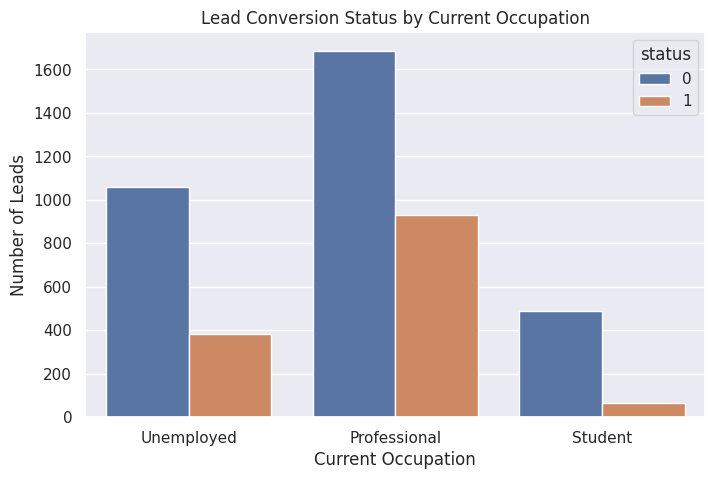

status,0,1
current_occupation,,
Professional,0.644878,0.355122
Student,0.882883,0.117117
Unemployed,0.734212,0.265788


In [ ]:
# Analyze the relationship between current_occupation and status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='current_occupation', hue='status')
plt.title('Lead Conversion Status by Current Occupation')
plt.xlabel('Current Occupation')
plt.ylabel('Number of Leads')
plt.show()

# Calculate the conversion rate per occupation
occupation_conversion_rate = df.groupby('current_occupation')['status'].value_counts(normalize=True).unstack()
display(occupation_conversion_rate)

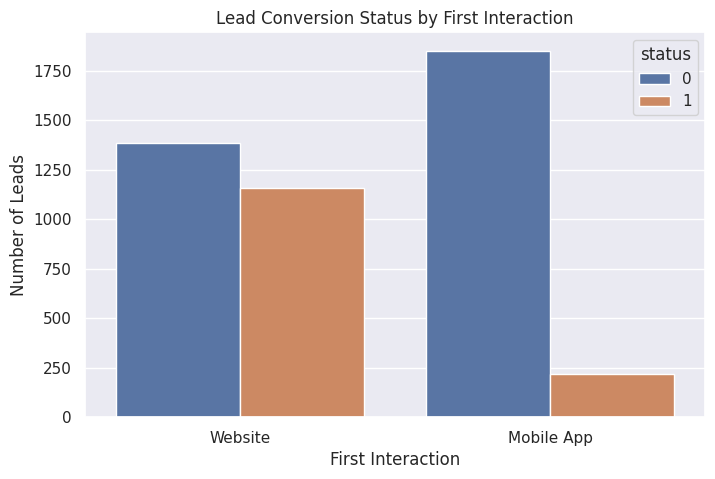

status,0,1
first_interaction,,
Mobile App,0.894686,0.105314
Website,0.544060,0.455940


In [ ]:
# Analyze the relationship between first_interaction and status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='first_interaction', hue='status')
plt.title('Lead Conversion Status by First Interaction')
plt.xlabel('First Interaction')
plt.ylabel('Number of Leads')
plt.show()

# Calculate the conversion rate per first interaction type
interaction_conversion_rate = df.groupby('first_interaction')['status'].value_counts(normalize=True).unstack()
display(interaction_conversion_rate)

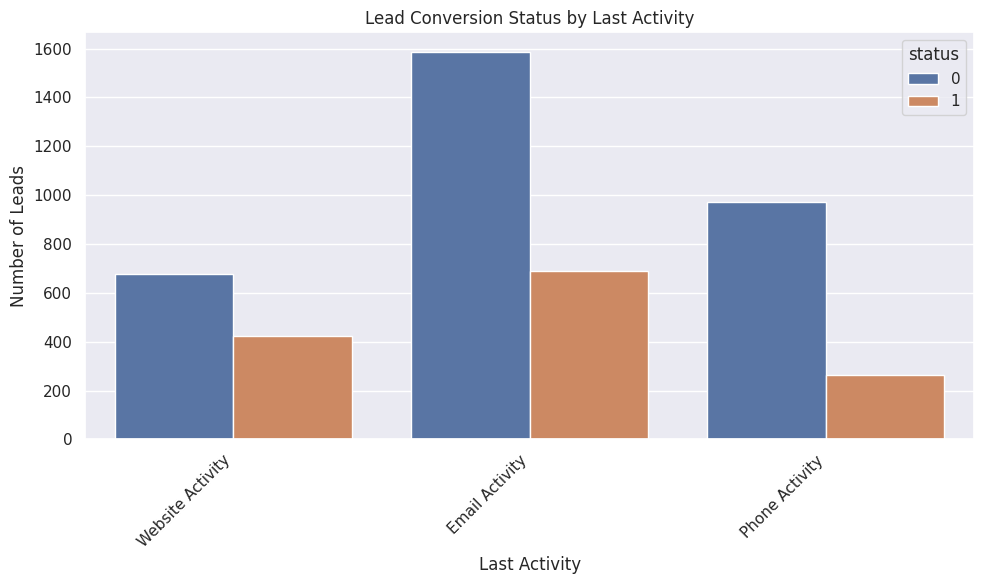

status,0,1
last_activity,,
Email Activity,0.696664,0.303336
Phone Activity,0.786872,0.213128
Website Activity,0.615455,0.384545


In [ ]:
# Analyze the relationship between last_activity and status
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='last_activity', hue='status')
plt.title('Lead Conversion Status by Last Activity')
plt.xlabel('Last Activity')
plt.ylabel('Number of Leads')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate the conversion rate per last activity type
last_activity_conversion_rate = df.groupby('last_activity')['status'].value_counts(normalize=True).unstack()
display(last_activity_conversion_rate)

Conversion rate for Print Media Type 1:


<Axes: xlabel='print_media_type1'>

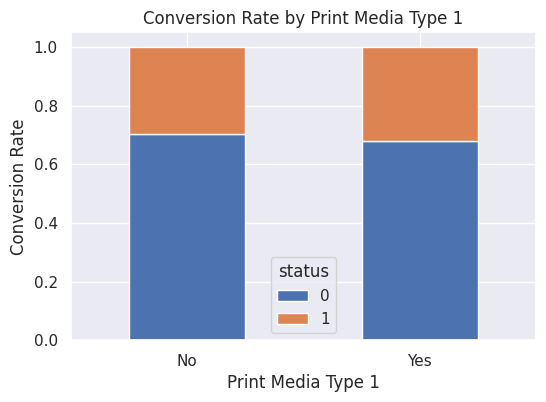


Conversion rate for Print Media Type 2:


<Axes: xlabel='print_media_type2'>

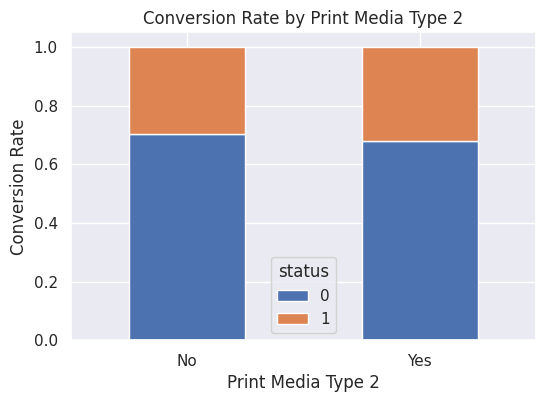


Conversion rate for Digital Media:


<Axes: xlabel='digital_media'>

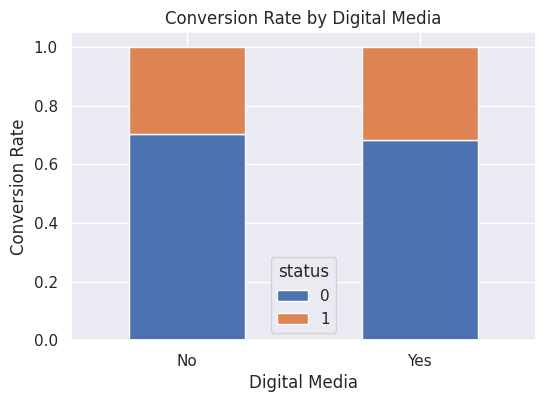


Conversion rate for Educational Channels:


<Axes: xlabel='educational_channels'>

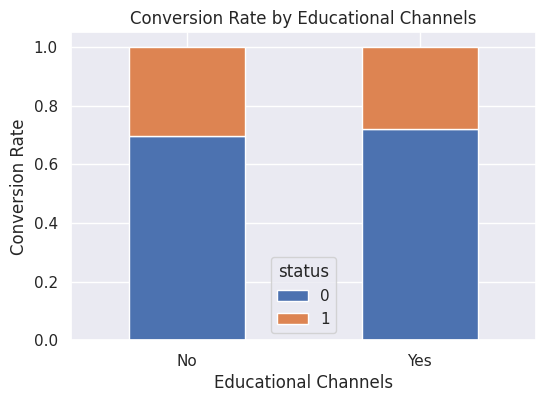


Conversion rate for Referral:


<Axes: xlabel='referral'>

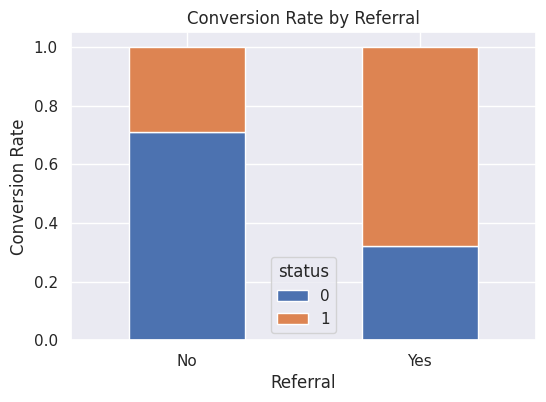

In [ ]:
# Analyze conversion rates for print_media_type1
print("Conversion rate for Print Media Type 1:")
display(df.groupby('print_media_type1')['status'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, figsize=(6, 4)))
plt.title('Conversion Rate by Print Media Type 1')
plt.xlabel('Print Media Type 1')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()


# Analyze conversion rates for print_media_type2
print("\nConversion rate for Print Media Type 2:")
display(df.groupby('print_media_type2')['status'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, figsize=(6, 4)))
plt.title('Conversion Rate by Print Media Type 2')
plt.xlabel('Print Media Type 2')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

# Analyze conversion rates for digital_media
print("\nConversion rate for Digital Media:")
display(df.groupby('digital_media')['status'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, figsize=(6, 4)))
plt.title('Conversion Rate by Digital Media')
plt.xlabel('Digital Media')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

# Analyze conversion rates for educational_channels
print("\nConversion rate for Educational Channels:")
display(df.groupby('educational_channels')['status'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, figsize=(6, 4)))
plt.title('Conversion Rate by Educational Channels')
plt.xlabel('Educational Channels')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

# Analyze conversion rates for referral
print("\nConversion rate for Referral:")
display(df.groupby('referral')['status'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, figsize=(6, 4)))
plt.title('Conversion Rate by Referral')
plt.xlabel('Referral')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

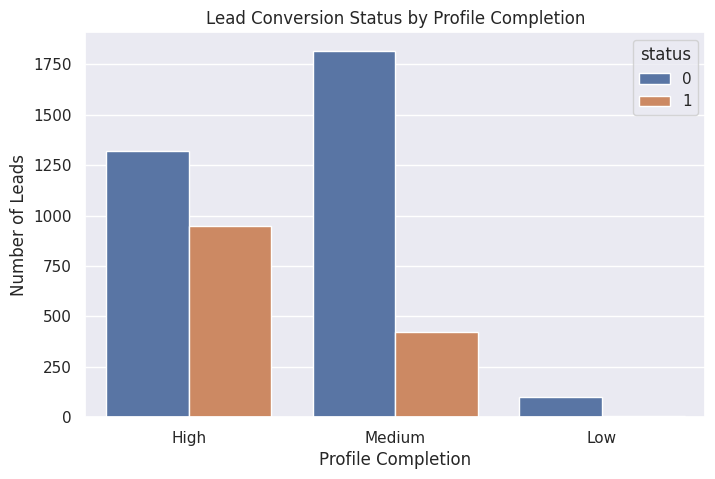

status,0,1
profile_completed,,
High,0.582155,0.417845
Low,0.925234,0.074766
Medium,0.811245,0.188755


In [ ]:
# Analyze the relationship between profile_completed and status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='profile_completed', hue='status')
plt.title('Lead Conversion Status by Profile Completion')
plt.xlabel('Profile Completion')
plt.ylabel('Number of Leads')
plt.show()

# Calculate the conversion rate per profile completion level
profile_completion_conversion_rate = df.groupby('profile_completed')['status'].value_counts(normalize=True).unstack()
display(profile_completion_conversion_rate)

#### Observations:

Current Occupation: Professionals have the highest conversion rate, followed by unemployed individuals, and then students. This suggests that the course offerings might be more appealing or relevant to working professionals.

First Interaction: Leads who first interacted through the website have a significantly higher conversion rate compared to those who used the mobile app. This could indicate that the website provides a better initial experience or more comprehensive information.

Last Activity: Leads whose last activity was on the website have the highest conversion rate, followed by email activity, and then phone activity. This might suggest that engaging with the platform directly or through email communication is more effective for conversion.

Marketing Channels: Referrals and educational channels seem to be the most effective marketing channels in terms of lead conversion, followed by digital media and then print media.

Profile Completion: There is a clear positive relationship between the level of profile completion and the conversion rate. Leads with a 'High' profile completion have a much higher conversion rate than those with 'Medium' or 'Low' completion. This suggests that prospects who provide more information are more serious or engaged.

These insights can be valuable in understanding which lead characteristics and interactions are associated with higher conversion rates, which can inform marketing and sales strategies.

### Numerical columns

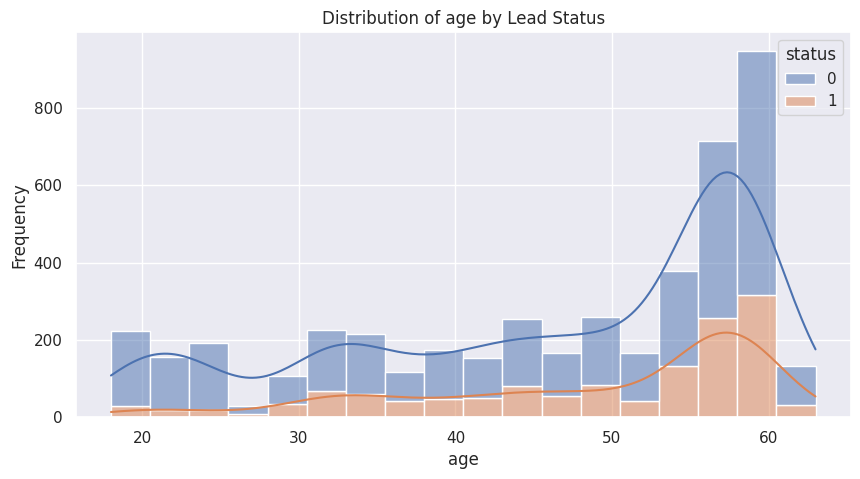

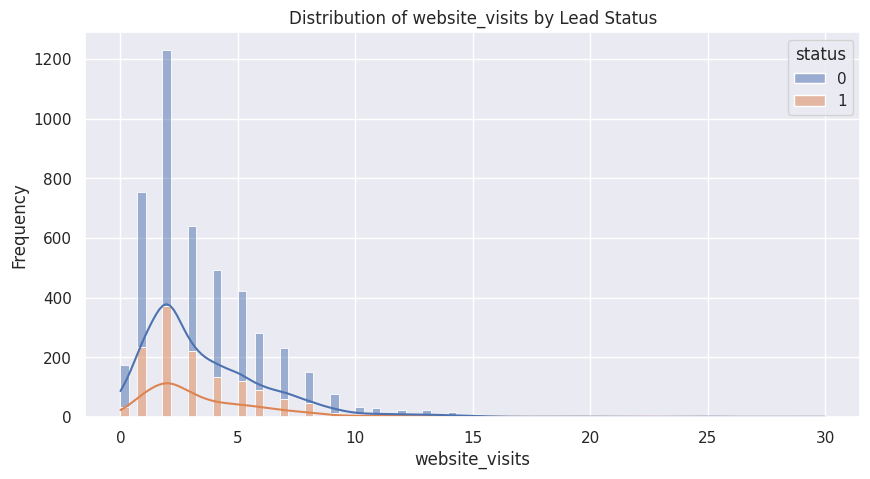

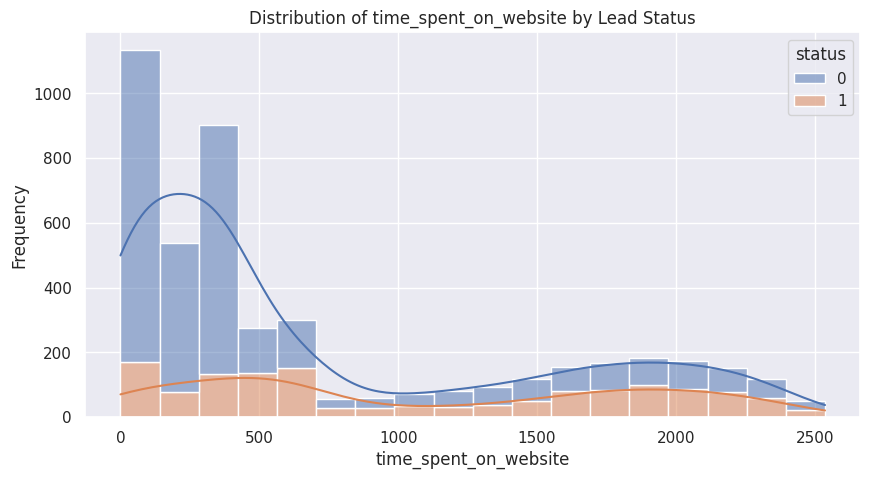

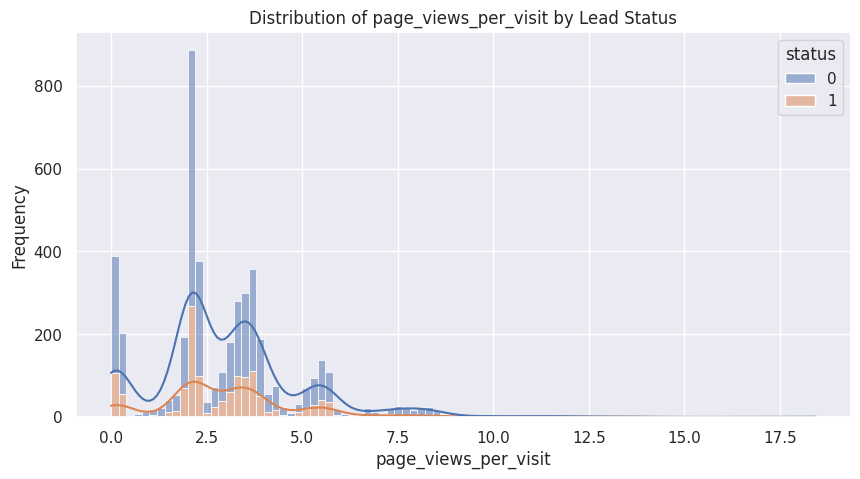

In [ ]:
numerical_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']

for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x=col, hue='status', kde=True, multiple='stack')
    plt.title(f'Distribution of {col} by Lead Status')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

#### Observations:

Age: The distribution of age seems to be somewhat similar between converted and unconverted leads, with a broad range of ages in both groups. There isn't a clearly distinct age group that is significantly more likely to convert based on these histograms alone.

Website Visits: Leads who converted tend to have a slightly higher number of website visits compared to those who didn't convert. The distribution for converted leads appears to be shifted slightly towards more visits.

Time Spent on Website: There's a noticeable difference in the time spent on the website. Converted leads generally spend more time on the website than unconverted leads. This is a strong indicator of engagement.

Page Views Per Visit: Similar to time spent on the website, leads who convert tend to have a higher average number of page views per visit. This further supports the idea that more engaged leads (those viewing more pages per visit) are more likely to convert.

Overall, the numerical variables related to website interaction (website_visits, time_spent_on_website, and page_views_per_visit) show clearer differences between converted and unconverted leads than age does. Higher engagement on the website appears to be associated with a higher likelihood of conversion.

### Statistical Tests to Complement EDA

To provide statistical support for the relationships observed in the visual EDA, we will perform Chi-Square tests for categorical variables and ANOVA tests for numerical variables against the target variable 'status'.

In [ ]:
from scipy.stats import chi2_contingency

# Chi-Square Test for Categorical Variables vs. Status
# Use original column names before one-hot encoding
categorical_cols_for_test = ["current_occupation", "first_interaction", 'profile_completed', 'last_activity',
                             'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']

# We need to reload the original data or use a copy before one-hot encoding
# Let's reload the data for this specific cell to perform the tests on original columns
# Assuming the original data path is correct
try:
    df_original = pd.read_csv('/content/drive/MyDrive/ML and AI /Classification and Hypothesis Testing/Project 2/ExtraaLearn.csv')
except FileNotFoundError:
    print("Error: Original data file not found. Please ensure the file path is correct.")
    # Exit or handle the error appropriately if the file is not found
    # For now, we'll assume the file exists at the specified path

print("Chi-Square Test Results:")
for col in categorical_cols_for_test:
    # Create a contingency table using the original data
    contingency_table = pd.crosstab(df_original[col], df_original['status'])

    # Perform the Chi-Square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print(f"\n--- Chi-Square Test for {col} and Status ---")
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")

    # Interpret the p-value
    alpha = 0.05
    if p < alpha:
        print(f"Conclusion: Reject null hypothesis. There is a statistically significant association between {col} and Status.")
    else:
        print(f"Conclusion: Fail to reject null hypothesis. There is no statistically significant association between {col} and Status (at alpha={alpha}).")

Chi-Square Test Results:

--- Chi-Square Test for current_occupation and Status ---
Chi-Square Statistic: 134.5990
P-value: 0.0000
Conclusion: Reject null hypothesis. There is a statistically significant association between current_occupation and Status.

--- Chi-Square Test for first_interaction and Status ---
Chi-Square Statistic: 668.0814
P-value: 0.0000
Conclusion: Reject null hypothesis. There is a statistically significant association between first_interaction and Status.

--- Chi-Square Test for profile_completed and Status ---
Chi-Square Statistic: 308.4293
P-value: 0.0000
Conclusion: Reject null hypothesis. There is a statistically significant association between profile_completed and Status.

--- Chi-Square Test for last_activity and Status ---
Chi-Square Statistic: 82.0879
P-value: 0.0000
Conclusion: Reject null hypothesis. There is a statistically significant association between last_activity and Status.

--- Chi-Square Test for print_media_type1 and Status ---
Chi-Square S

In [ ]:
from scipy.stats import f_oneway

# ANOVA Test for Numerical Variables vs. Status
numerical_cols_for_test = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']

print("ANOVA Test Results:")
for col in numerical_cols_for_test:
    # Create groups for ANOVA based on 'status'
    group0 = df[df['status'] == 0][col]
    group1 = df[df['status'] == 1][col]

    # Perform the ANOVA test
    f_statistic, p_value = f_oneway(group0.dropna(), group1.dropna()) # Drop NaNs just in case, though we know there are none

    print(f"\n--- ANOVA Test for {col} and Status ---")
    print(f"F-statistic: {f_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

    # Interpret the p-value
    alpha = 0.05
    if p_value < alpha:
        print(f"Conclusion: Reject null hypothesis. There is a statistically significant difference in the mean of {col} between converted and unconverted leads.")
    else:
        print(f"Conclusion: Fail to reject null hypothesis. There is no statistically significant difference in the mean of {col} between converted and unconverted leads (at alpha={alpha}).")

ANOVA Test Results:

--- ANOVA Test for age and Status ---
F-statistic: 69.7490
P-value: 0.0000
Conclusion: Reject null hypothesis. There is a statistically significant difference in the mean of age between converted and unconverted leads.

--- ANOVA Test for website_visits and Status ---
F-statistic: 0.2014
P-value: 0.6536
Conclusion: Fail to reject null hypothesis. There is no statistically significant difference in the mean of website_visits between converted and unconverted leads (at alpha=0.05).

--- ANOVA Test for time_spent_on_website and Status ---
F-statistic: 462.9819
P-value: 0.0000
Conclusion: Reject null hypothesis. There is a statistically significant difference in the mean of time_spent_on_website between converted and unconverted leads.

--- ANOVA Test for page_views_per_visit and Status ---
F-statistic: 0.0004
P-value: 0.9834
Conclusion: Fail to reject null hypothesis. There is no statistically significant difference in the mean of page_views_per_visit between converte

#### Observations about Chi-Square and ANOVA Test Results:

Based on the Chi-Square tests for categorical variables and ANOVA tests for numerical variables against the target variable 'status':

*   **Statistically Significant Associations (Categorical):** The Chi-Square tests indicate a statistically significant association between 'status' and the following categorical variables:
    *   `current_occupation` (p-value < 0.05)
    *   `first_interaction` (p-value < 0.05)
    *   `profile_completed` (p-value < 0.05)
    *   `last_activity` (p-value < 0.05)
    *   `referral` (p-value < 0.05)
    This supports the visual observations from the EDA that the distribution of converted leads differs across the categories of these variables.

*   **No Statistically Significant Association (Categorical):** The Chi-Square tests suggest no statistically significant association between 'status' and the following categorical variables at the 0.05 significance level:
    *   `print_media_type1` (p-value > 0.05)
    *   `print_media_type2` (p-value > 0.05)
    *   `digital_media` (p-value > 0.05)
    *   `educational_channels` (p-value > 0.05)
    While visual EDA might have shown slight differences, these tests indicate they are not statistically significant at the chosen alpha level across the population.

*   **Statistically Significant Difference in Mean (Numerical):** The ANOVA tests show a statistically significant difference in the mean of the following numerical variables between converted and unconverted leads:
    *   `age` (p-value < 0.05)
    *   `time_spent_on_website` (p-value < 0.05)
    This confirms that the average age and the average time spent on the website are statistically different for leads who convert compared to those who don't.

*   **No Statistically Significant Difference in Mean (Numerical):** The ANOVA tests suggest no statistically significant difference in the mean of the following numerical variables between converted and unconverted leads at the 0.05 significance level:
    *   `website_visits` (p-value > 0.05)
    *   `page_views_per_visit` (p-value > 0.05)
    This indicates that while there might be visual trends, the average number of website visits and page views per visit are not statistically different between the two conversion groups.

These statistical test results largely align with and strengthen many of the observations made during the visual EDA, providing statistical confidence in the relationships between several features and lead conversion status.

### Correlation Matrix

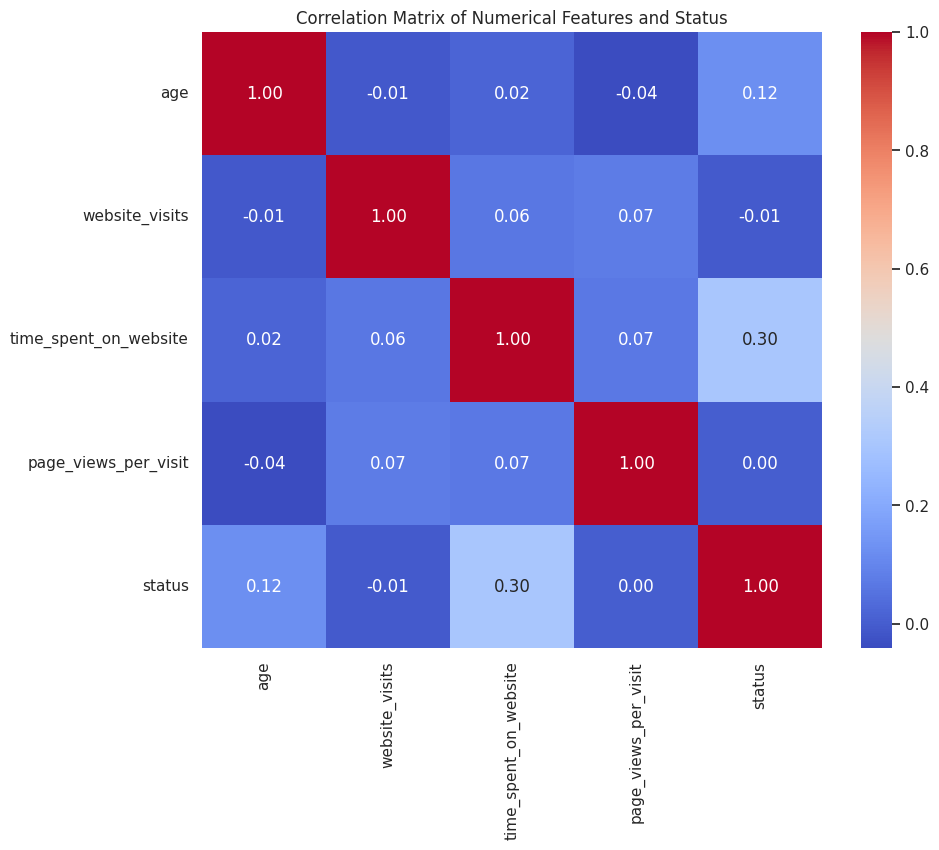

In [ ]:
# Check for correlations between numerical columns and status using a heatmap
numerical_cols_with_status = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'status']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols_with_status].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Status')
plt.show()

#### Observations:

Among the numerical features, time_spent_on_website is the strongest predictor of status, showing a moderate positive relationship. Other variables such as age, website_visits, and page_views_per_visit show very weak or no correlation, suggesting they have limited influence on status.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

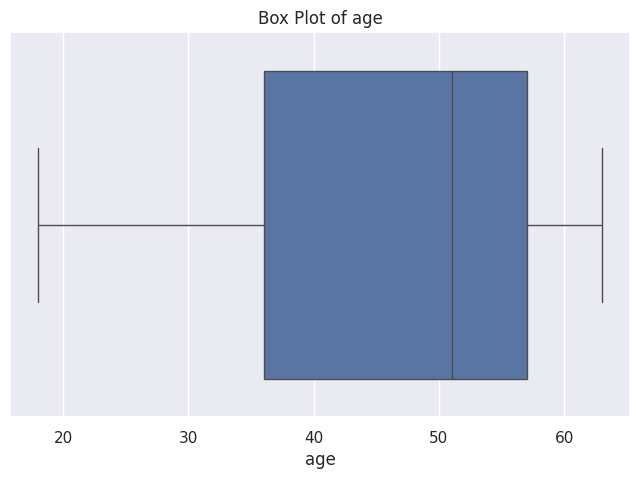

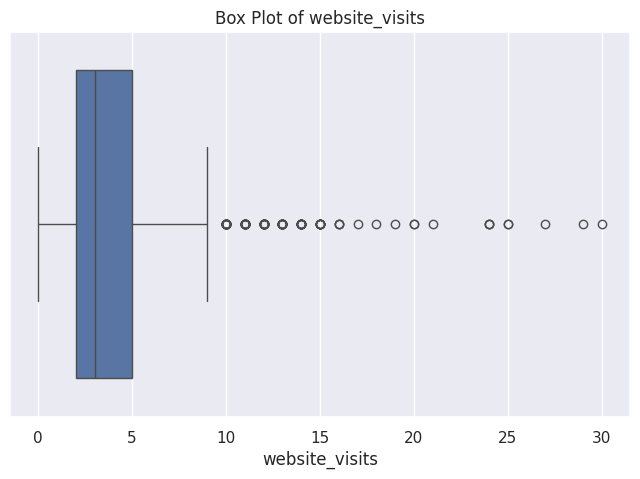

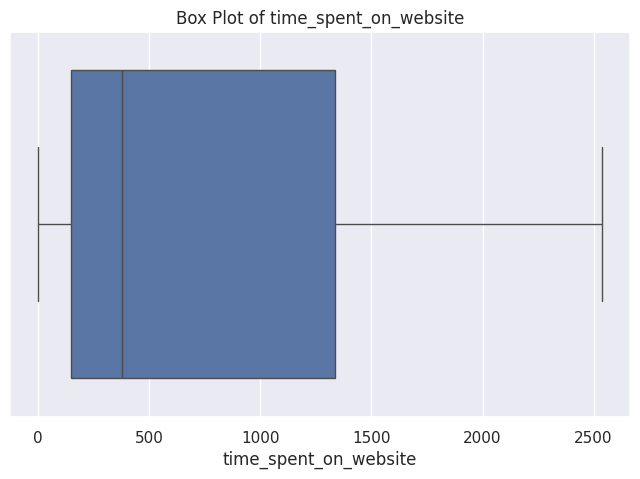

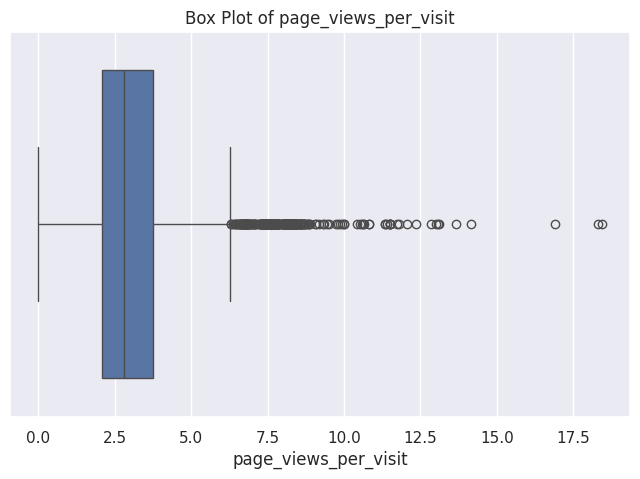

In [ ]:
# Check for outliers in numerical columns using box plots
numerical_cols = ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=col)
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

#### Observations about Outliers from Box Plots:

Age: The box plot for age shows some potential outliers on both the lower and higher ends, but the distribution is relatively concentrated around the median.

Website Visits: The box plot for website visits indicates a significant number of outliers on the higher end. This means there are some leads who have visited the website much more frequently than the majority.

Time Spent on Website: Similar to website visits, the box plot for time spent on the website also shows a considerable number of outliers on the higher end. This suggests that a subset of leads are spending an exceptionally long time on the website.

Page Views Per Visit: The box plot for page views per visit reveals a large number of outliers on the higher end. This implies that some leads are viewing a significantly higher number of pages per visit compared to the average.

**Note on Outliers:** Even so outliers were identified in numerical features during the EDA, they will not be explicitly treated in these preprocessing steps. This decision is made because tree-based models (Decision Trees and Random Forests), which we plan to use, are generally less sensitive to outliers compared to other types of models. Explicitly treating outliers might not be necessary and could potentially remove valuable information.

In [ ]:
# Drop the ID column as it is not useful for modeling
df = df.drop('ID', axis=1)

# Convert binary categorical columns to numerical (0 and 1)
binary_cols = ['print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
for col in binary_cols:
    df[col] = df[col].apply(lambda x: 1 if x == 'Yes' else 0)

# Convert 'first_interaction' and 'last_activity' using one-hot encoding
df = pd.get_dummies(df, columns=['first_interaction', 'last_activity'], drop_first=True)

# Convert 'profile_completed' to numerical using mapping
profile_completion_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['profile_completed'] = df['profile_completed'].map(profile_completion_mapping)

# Convert 'current_occupation' using one-hot encoding
df = pd.get_dummies(df, columns=['current_occupation'], drop_first=True)

# Display the first few rows of the preprocessed DataFrame
display(df.head())

,age,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status,first_interaction_Website,last_activity_Phone Activity,last_activity_Website Activity,current_occupation_Student,current_occupation_Unemployed
0,57,2,7,1639,1.861,1,0,1,0,0,1,True,False,True,False,True
1,56,1,2,83,0.320,0,0,0,1,0,0,False,False,True,False,False
2,52,1,3,330,0.074,0,0,1,0,0,0,True,False,True,False,False
3,53,2,4,464,2.057,0,0,0,0,0,1,True,False,True,False,True
4,23,2,4,600,16.914,0,0,0,0,0,0,True,False,False,True,False


#### Data Preprocessing Steps:

Dropping the ID column: The ID column was dropped because it's a unique identifier for each lead and doesn't provide any predictive information for the model.

Converting binary categorical columns: Columns like print_media_type1, print_media_type2, digital_media, educational_channels, and referral which had 'Yes' and 'No' values were converted into numerical representation (1 for 'Yes' and 0 for 'No'). This is necessary for most machine learning algorithms which require numerical input.

One-hot encoding for multi-category nominal columns: first_interaction, last_activity and current_occupation columns, which have more than two categories and no inherent order, were converted using one-hot encoding. This creates new binary columns for each unique category within the original column (e.g., first_interaction_Website, last_activity_Phone Activity, etc.). The drop_first=True argument is used to avoid multicollinearity.

Mapping for ordinal categorical columns: The profile_completed column has ordered categories ('Low', 'Medium', 'High'). This column was converted to numerical values (0, 1, and 2 respectively) using a mapping. This preserves the ordinal relationship between the categories.



## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
display(df.head())

,age,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status,first_interaction_Website,last_activity_Phone Activity,last_activity_Website Activity,current_occupation_Student,current_occupation_Unemployed
0,57,2,7,1639,1.861,1,0,1,0,0,1,True,False,True,False,True
1,56,1,2,83,0.320,0,0,0,1,0,0,False,False,True,False,False
2,52,1,3,330,0.074,0,0,1,0,0,0,True,False,True,False,False
3,53,2,4,464,2.057,0,0,0,0,0,1,True,False,True,False,True
4,23,2,4,600,16.914,0,0,0,0,0,0,True,False,False,True,False


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             4612 non-null   int64  
 1   profile_completed               4612 non-null   int64  
 2   website_visits                  4612 non-null   int64  
 3   time_spent_on_website           4612 non-null   int64  
 4   page_views_per_visit            4612 non-null   float64
 5   print_media_type1               4612 non-null   int64  
 6   print_media_type2               4612 non-null   int64  
 7   digital_media                   4612 non-null   int64  
 8   educational_channels            4612 non-null   int64  
 9   referral                        4612 non-null   int64  
 10  status                          4612 non-null   int64  
 11  first_interaction_Website       4612 non-null   bool   
 12  last_activity_Phone Activity    46

None

### Observations after Preprocessing:

After preprocessing, the DataFrame now has 16 columns. The 'ID' column has been removed, and several categorical columns have been transformed into numerical or boolean types.

*   The original binary columns ('print_media\_type1', 'print\_media\_type2', 'digital\_media', 'educational\_channels', 'referral') are now represented as integers (0 or 1).
*   'profile\_completed' has been mapped to numerical values (0, 1, 2).
*   'first\_interaction', 'last\_activity', and 'current\_occupation' have been one-hot encoded, resulting in new boolean columns (e.g., 'first\_interaction\_Website', 'last\_activity\_Phone Activity', etc.).

The data types now include integers, floats, and booleans, which are suitable for machine learning models. There are still no missing values, confirming that the preprocessing steps did not introduce any. The number of entries remains 4612.

## Building a Decision Tree model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Separate features (X) and target (y)
# Drop the status column to create the features DataFrame
X = df.drop('status', axis=1)
y = df['status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize the Decision Tree model with balanced class weights
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = dt_model.predict(X_test)

# Evaluate the model on the test set
print("Decision Tree Model Evaluation (Test Set - with balanced class weights):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))

# Make predictions on the training set
y_pred_train = dt_model.predict(X_train)

# Evaluate the model on the training set
print("\n" + "="*50 + "\n") # Separator for clarity
print("Decision Tree Model Evaluation (Training Set - with balanced class weights):")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_pred_train))

Decision Tree Model Evaluation (Test Set - with balanced class weights):
Accuracy: 0.8129

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       971
           1       0.68      0.71      0.69       413

    accuracy                           0.81      1384
   macro avg       0.78      0.78      0.78      1384
weighted avg       0.82      0.81      0.81      1384



Decision Tree Model Evaluation (Training Set - with balanced class weights):
Accuracy: 0.9997

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



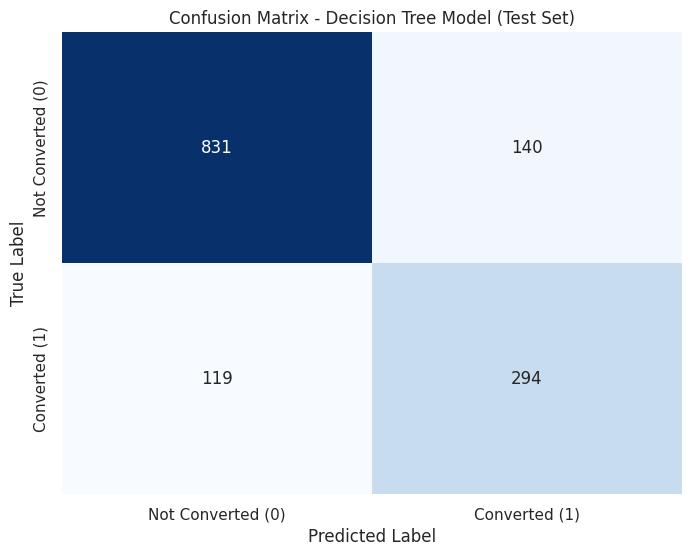

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix for the Decision Tree model on the test set
cm_dt = confusion_matrix(y_test, y_pred_test)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Converted (0)', 'Converted (1)'],
            yticklabels=['Not Converted (0)', 'Converted (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Model (Test Set)')
plt.show()

### Observations about the Decision Tree Model (with balanced class weights):

**Based on the evaluation metrics from the classification:**

*   **Accuracy:** The overall accuracy of the model is approximately 81.29% on the test set and 99.97% on the training set. This indicates that the model correctly predicts the status (converted or not converted) for about 81.29% of the leads in the test set and nearly perfectly on the training set.
*   **Precision:**
    *   For class 0 (Not Converted): The precision is 0.87 on the test set and 1.00 on the training set.
    *   For class 1 (Converted): The precision is 0.68 on the test set and 1.00 on the training set.
*   **Recall (Sensitivity):**
    *   For class 0 (Not Converted): The recall is 0.86 on the test set and 1.00 on the training set.
    *   For class 1 (Converted): The recall is 0.71 on the test set and 1.00 on the training set.
*   **F1-score:**
    *   For class 0: The F1-score is 0.87 on the test set and 1.00 on the training set.
    *   For class 1: The F1-score is 0.69 on the test set and 1.00 on the training set.
*   **Support:** This is the number of actual instances for each class in the test set (971 for not converted, 413 for converted) and training set (2264 for not converted, 964 for converted).

Comparing the training set performance to the test set performance, we observe a significant difference across all metrics (Accuracy, Precision, Recall, and F1-score). The model achieves almost perfect scores (1.00) on the training data but considerably lower scores on the test data. This large gap in performance between the training and test sets is a strong indication of **overfitting**. The Decision Tree model has learned the training data too well, including its noise and specific patterns, and is not generalizing effectively to unseen data in the test set.

**Based on the confusion matrix:**

The model correctly classifies most leads, showing stronger performance in identifying non-converted leads (class 0) than converted ones (class 1).
There are 119 missed conversions (false negatives), meaning 119 leads who actually converted were incorrectly predicted as not converted. This is an important consideration for business strategy.
The precision and recall trade-off appears balanced for the minority class (Class 1), suggesting the model is effective but could potentially benefit from tuning to improve recall for converted leads, depending on whether minimizing false negatives is a higher priority.

The use of `class_weight='balanced'` helped address the class imbalance during training, but the overfitting issue still needs to be addressed, likely through techniques like pruning.

## Do we need to prune the tree?

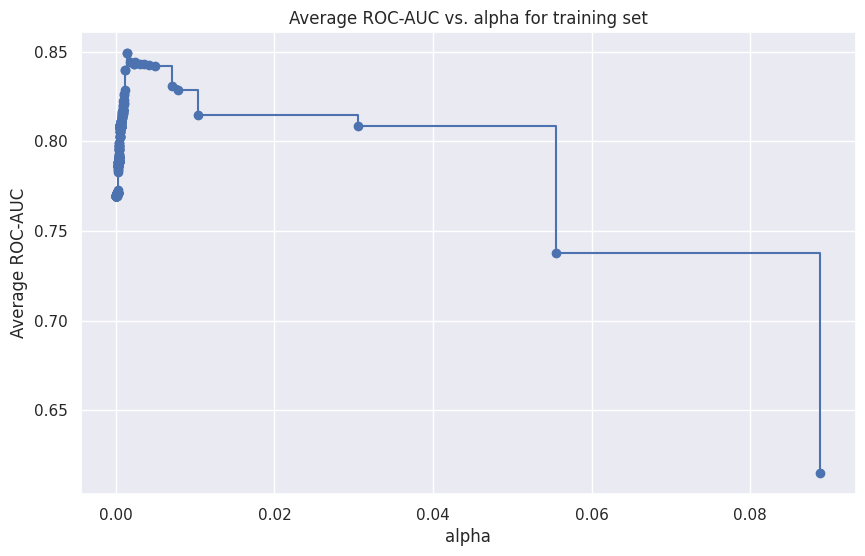

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, make_scorer

# Determine the optimal ccp_alpha
path = dt_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train Decision Trees with different ccp_alpha values and evaluate using ROC-AUC
clfs = []
roc_auc_scores = [] # Changed to store ROC-AUC scores
roc_auc_scorer = make_scorer(roc_auc_score) # Create a scorer for roc_auc

for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha, class_weight='balanced')
    clf.fit(X_train, y_train)
    clfs.append(clf)

    # Evaluate using cross-validation with ROC-AUC scorer
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring=roc_auc_scorer) # Use roc_auc_scorer
    roc_auc_scores.append(np.mean(scores)) # Store average ROC-AUC


# Plot the ROC-AUC vs ccp_alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, roc_auc_scores, marker='o', drawstyle="steps-post") # Plot roc_auc_scores
plt.xlabel("alpha")
plt.ylabel("Average ROC-AUC") # Changed label
plt.title("Average ROC-AUC vs. alpha for training set") # Changed title
plt.show()

### Decision Tree Pruning Interpretation

The ROC-AUC score is highest (~0.85) when alpha is small (≈ 0.001–0.005).

As alpha increases beyond 0.01, the ROC-AUC gradually declines.

After about α > 0.05, the ROC-AUC drops sharply below 0.70, indicating severe underfitting.

Conclusion:
The model performs best with light pruning.
There is no need for heavy pruning, as it reduces model accuracy significantly.

In [ ]:
# Choose the optimal ccp_alpha value from the plot in cell 66e7cb60
optimal_ccp_alpha = 0.001 # Replace with your chosen ccp_alpha

# Initialize the pruned Decision Tree model with the chosen ccp_alpha and balanced class weights
pruned_dt_model = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha, class_weight='balanced')

# Train the pruned model
pruned_dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_pruned_test = pruned_dt_model.predict(X_test)

# Evaluate the pruned model on the test set
print(f"Pruned Decision Tree Model Evaluation (Test Set - ccp_alpha={optimal_ccp_alpha}):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pruned_test):.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_pruned_test))

# Make predictions on the training set
y_pred_pruned_train = pruned_dt_model.predict(X_train)

# Evaluate the pruned model on the training set
print("\n" + "="*50 + "\n") # Separator for clarity
print(f"Pruned Decision Tree Model Evaluation (Training Set - ccp_alpha={optimal_ccp_alpha}):")
print(f"Accuracy: {accuracy_score(y_train, y_pred_pruned_train):.4f}")
print("\nClassification Report (Training Set):")
print(classification_report(y_pred_pruned_train, y_train)) # Note: Swapped y_train and y_pred_pruned_train to match expected classification_report format

Pruned Decision Tree Model Evaluation (Test Set - ccp_alpha=0.001):
Accuracy: 0.8483

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       971
           1       0.71      0.84      0.77       413

    accuracy                           0.85      1384
   macro avg       0.82      0.84      0.83      1384
weighted avg       0.86      0.85      0.85      1384



Pruned Decision Tree Model Evaluation (Training Set - ccp_alpha=0.001):
Accuracy: 0.8770

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2125
           1       0.87      0.76      0.81      1103

    accuracy                           0.88      3228
   macro avg       0.87      0.85      0.86      3228
weighted avg       0.88      0.88      0.87      3228



### Interpretation of Pruned Decision Tree Results:

Based on the evaluation metrics from the classification the Decision Tree was pruned with `ccp_alpha = 0.001`:

*   **Reduced Overfitting:** Comparing the training and test set metrics to the unpruned model, the gap between training accuracy (0.8770) and test accuracy (0.8483) is significantly smaller. This indicates that pruning was effective in reducing overfitting.
*   **Improved Generalization:** The test set accuracy of the pruned model (0.8483) is higher than that of the unpruned model (0.8129), suggesting better performance on unseen data.
*   **Performance on Converted Leads (Class 1):**
    *   The **Recall** for Class 1 on the test set is 0.84, which is a notable improvement over the unpruned model's recall of 0.71. This means the pruned model is better at identifying leads who will actually convert.
    *   The **Precision** for Class 1 on the test set is 0.71, a slight increase from the unpruned model (0.68).
    *   The **F1-score** for Class 1 on the test set is 0.77, showing a better balance between precision and recall for the minority class compared to the unpruned model (0.69).

In conclusion, pruning the Decision Tree with a `ccp_alpha` of 0.001 resulted in a model that generalizes better to new data and is more effective at identifying leads who are likely to convert, as evidenced by the improved recall and F1-score for the converted class on the test set.

## Building a Random Forest model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model with balanced class weights
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_test = rf_model.predict(X_test)

# Evaluate the model on the test set
print("Random Forest Model Evaluation (Test Set - with balanced class weights):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_rf_test))

# Make predictions on the training set
y_pred_rf_train = rf_model.predict(X_train)

# Evaluate the model on the training set
print("\n" + "="*50 + "\n") # Separator for clarity
print("Random Forest Model Evaluation (Training Set - with balanced class weights):")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_pred_rf_train))

Random Forest Model Evaluation (Test Set - with balanced class weights):
Accuracy: 0.8540

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       971
           1       0.79      0.70      0.74       413

    accuracy                           0.85      1384
   macro avg       0.83      0.81      0.82      1384
weighted avg       0.85      0.85      0.85      1384



Random Forest Model Evaluation (Training Set - with balanced class weights):
Accuracy: 0.9997

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



### Interpretation of Random Forest Model Results:

Based on the evaluation metrics from the classification:

*   **Accuracy:** The overall accuracy is 0.8540 on the test set and 0.9997 on the training set. Similar to the unpruned Decision Tree, the training accuracy is very high, while the test accuracy is lower. This still suggests some degree of overfitting, although less pronounced than the initial unpruned Decision Tree.
*   **Precision:**
    *   Class 0 (Not Converted): 0.88 on test, 1.00 on training.
    *   Class 1 (Converted): 0.79 on test, 1.00 on training.
*   **Recall (Sensitivity):**
    *   Class 0 (Not Converted): 0.92 on test, 1.00 on training.
    *   Class 1 (Converted): 0.70 on test, 1.00 on training.
*   **F1-score:**
    *   Class 0 (Not Converted): 0.90 on test, 1.00 on training.
    *   Class 1 (Converted): 0.74 on test, 1.00 on training.
*   **Support:** 971 for Class 0 and 413 for Class 1 on the test set; 2264 for Class 0 and 964 for Class 1 on the training set.

**Observations and Comparison:**

*   **Overfitting:** While not as severe as the unpruned Decision Tree, the significant difference between training and test scores indicates that the Random Forest model is also overfitting to the training data.
*   **Overall Performance:** The Random Forest model achieves a test accuracy of 0.8540, which is slightly higher than the pruned Decision Tree (0.8483).
*   **Performance on Converted Leads (Class 1):**
    *   The **Precision** for Class 1 on the test set (0.79) is higher than both the unpruned (0.68) and pruned (0.71) Decision Trees. This means when the Random Forest predicts a conversion, it is more likely to be correct.
    *   The **Recall** for Class 1 on the test set (0.70) is slightly lower than the pruned Decision Tree (0.84) but similar to the unpruned Decision Tree (0.71). This means the Random Forest is slightly less effective at identifying all actual converted leads compared to the pruned Decision Tree.
    *   The **F1-score** for Class 1 on the test set (0.74) is slightly lower than the pruned Decision Tree (0.77) but higher than the unpruned Decision Tree (0.69).

In summary, the Random Forest model shows slightly better overall accuracy and significantly better precision for predicting converted leads compared to both Decision Tree models. However, the pruned Decision Tree has a higher recall for the converted class. The choice between the pruned Decision Tree and the Random Forest might depend on whether identifying as many true positives (Recall) or having higher confidence in positive predictions (Precision) is more critical for ExtraaLearn. Both models still exhibit some overfitting, which could potentially be addressed further through hyperparameter tuning for the Random Forest.

Random Forest Feature Importances:


,0
time_spent_on_website,0.276736
first_interaction_Website,0.181804
page_views_per_visit,0.113685
profile_completed,0.112963
age,0.108509
website_visits,0.064879
last_activity_Phone Activity,0.030932
current_occupation_Unemployed,0.024028
last_activity_Website Activity,0.020646
current_occupation_Student,0.016731


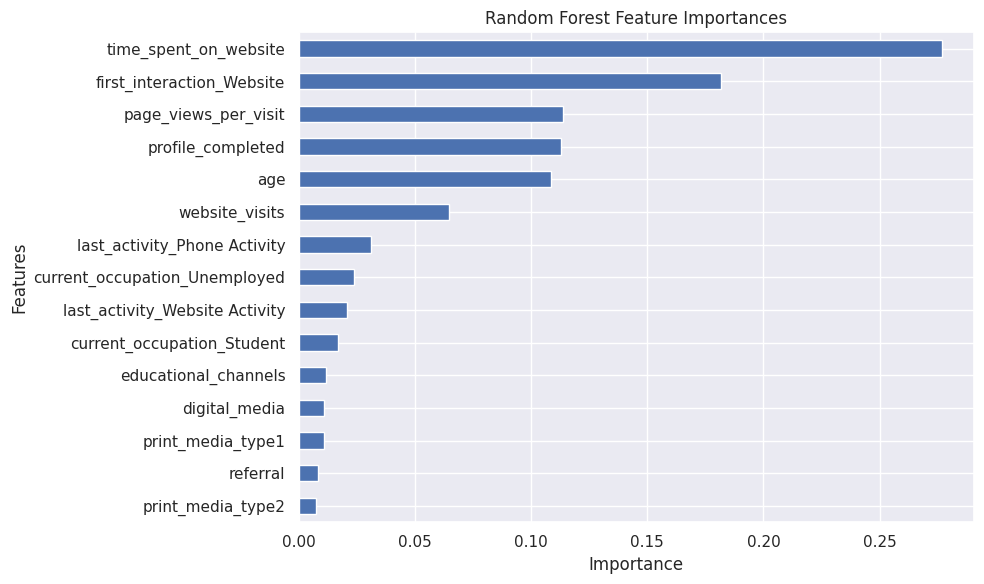

In [ ]:
# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Get the names of the features
features = X_train.columns

# Create a pandas Series of feature importances with feature names as index
feature_importance_series = pd.Series(feature_importances, index=features)

# Sort feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# Display the sorted feature importances
print("Random Forest Feature Importances:")
display(sorted_feature_importances)

# Optionally, visualize the feature importances as a horizontal bar plot
plt.figure(figsize=(10, 6))
sorted_feature_importances.plot(kind='barh') # Changed to 'barh' for horizontal plot
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance') # Swapped labels for horizontal plot
plt.ylabel('Features') # Swapped labels for horizontal plot
plt.gca().invert_yaxis() # Invert y-axis to have most important feature at the top
plt.tight_layout()
plt.show()

### Feature intepretation:

* time_spent_on_website is the most influential feature, indicating that users who spend more time on the website are far more likely to convert.

* first_interaction_Website is the second most important factor — leads who first engage through the website tend to convert more than those using the mobile app.

* age_views_per_visit and profile_completed also play strong roles, suggesting that higher engagement and profile completion levels increase conversion likelihood.

* age and website_visits have moderate importance, implying that both demographic and interaction frequency contribute to predicting conversions.

* Other variables like phone activity, occupation, and marketing channels have relatively lower importance, showing less direct impact on lead conversion outcomes.

Website engagement features — especially time spent and first interaction type — are the primary drivers of lead conversion, highlighting the importance of improving the online experience and encouraging deeper engagement.

## Do we need to prune the tree?

## Manual tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize the Random Forest model with hyperparameters to control overfitting
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced_subsample'
)

# Train the model
rf_model_tuned.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_tuned_test = rf_model_tuned.predict(X_test)

# Evaluate the tuned model on the test set
print("Tuned Random Forest Model Evaluation (Test Set - with overfitting controls):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_tuned_test):.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_rf_tuned_test))

# Calculate ROC-AUC on the test set
roc_auc_tuned_test = roc_auc_score(y_test, rf_model_tuned.predict_proba(X_test)[:, 1])
print(f"\nROC-AUC Score (Test Set): {roc_auc_tuned_test:.4f}")


# Make predictions on the training set
y_pred_rf_tuned_train = rf_model_tuned.predict(X_train)

# Evaluate the model on the training set
print("\n" + "="*50 + "\n") # Separator for clarity
print("Tuned Random Forest Model Evaluation (Training Set - with overfitting controls):")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_tuned_train):.4f}")
print("\nClassification Report (Training Set):")
print(classification_report(y_train, y_pred_rf_tuned_train))

Tuned Random Forest Model Evaluation (Test Set - with overfitting controls):
Accuracy: 0.8562

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       971
           1       0.72      0.85      0.78       413

    accuracy                           0.86      1384
   macro avg       0.83      0.85      0.84      1384
weighted avg       0.87      0.86      0.86      1384


ROC-AUC Score (Test Set): 0.9277


Tuned Random Forest Model Evaluation (Training Set - with overfitting controls):
Accuracy: 0.8801

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      2264
           1       0.76      0.88      0.81       964

    accuracy                           0.88      3228
   macro avg       0.85      0.88      0.86      3228
weighted avg       0.89      0.88      0.88      3228



### Interpretation of Tuned Random Forest Model Results:

Based on the evaluation metrics from the classification report for the Random Forest model with hyperparameters set to control overfitting:

*   **Accuracy:** The overall accuracy is 0.8562 on the test set and 0.8801 on the training set. Compared to the previous (untuned) Random Forest model (test accuracy ~0.8540, training accuracy ~0.9997), the gap between training and test accuracy has significantly reduced. This indicates that the chosen hyperparameters (`max_depth`, `min_samples_leaf`, `n_estimators`) were effective in reducing overfitting.
*   **Precision:**
    *   Class 0 (Not Converted): 0.93 on test, 0.94 on training.
    *   Class 1 (Converted): 0.72 on test, 0.76 on training.
*   **Recall (Sensitivity):**
    *   Class 0 (Not Converted): 0.86 on test, 0.88 on training.
    *   Class 1 (Converted): 0.85 on test, 0.88 on training.
*   **F1-score:**
    *   Class 0 (Not Converted): 0.89 on test, 0.91 on training.
    *   Class 1 (Converted): 0.78 on test, 0.81 on training.
*   **Support:** 971 for Class 0 and 413 for Class 1 on the test set; 2264 for Class 0 and 964 for Class 1 on the training set.

**Observations and Comparison:**

*   **Reduced Overfitting:** The significantly smaller difference between training and test scores (accuracy gap of ~0.0239) compared to the untuned Random Forest (accuracy gap of ~0.1457) demonstrates that the hyperparameters successfully reduced overfitting.
*   **Improved Generalization:** The test set accuracy (0.8562) is slightly higher than both the unpruned Decision Tree (0.8129), the pruned Decision Tree (0.8483), and the untuned Random Forest (0.8540).
*   **Balanced Performance on Classes:** This tuned Random Forest model achieves a better balance between precision and recall for both classes on the test set compared to the untuned Random Forest. Notably, the recall for the converted class (Class 1) on the test set (0.85) is a significant improvement over the untuned Random Forest (0.70) and is comparable to the pruned Decision Tree (0.84). The precision for Class 1 (0.72) is slightly lower than the untuned Random Forest (0.79) but higher than the unpruned Decision Tree (0.68) and similar to the pruned Decision Tree (0.71). The F1-score for Class 1 (0.78) is the highest among all models evaluated so far.

In conclusion, applying hyperparameters to control overfitting in the Random Forest model resulted in the best performing model among those evaluated. It shows good generalization to unseen data, significantly reduced overfitting compared to the untuned Random Forest, and achieves the best balance between precision and recall for predicting converted leads (highest F1-score for Class 1 on the test set). This tuned Random Forest model appears to be the most suitable for identifying leads who are likely to convert.

## GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, roc_auc_score

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Initialize the Random Forest Classifier
# We will use the default parameters here as GridSearchCV will search the grid
rf_grid = RandomForestClassifier(random_state=42)

# Define the scoring metric (ROC-AUC is good for imbalanced datasets)
scorer = make_scorer(roc_auc_score)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_grid, param_grid=param_grid,
                           scoring=scorer, cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
# This may take some time depending on the grid size and data
print("Performing GridSearchCV...")
grid_search.fit(X_train, y_train)

# Print the best parameters and best score found by GridSearchCV
print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)
print("\nBest cross-validation ROC-AUC score:")
print(grid_search.best_score_)

# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Now you can evaluate this best model on the test set
# Evaluate the best model on the test set
y_pred_best_test = best_rf_model.predict(X_test)
print("\nEvaluation of the Best Random Forest Model from GridSearchCV (Test Set):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_test):.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_best_test))
print("\nROC-AUC Score (Test Set):")
print(roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])) # Calculate ROC-AUC on test set

Performing GridSearchCV...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best parameters found by GridSearchCV:
{'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best cross-validation ROC-AUC score:
0.8410510331164291

Evaluation of the Best Random Forest Model from GridSearchCV (Test Set):
Accuracy: 0.8461

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.94      0.83      0.88       971
           1       0.69      0.87      0.77       413

    accuracy                           0.85      1384
   macro avg       0.82      0.85      0.83      1384
weighted avg       0.87      0.85      0.85      1384


ROC-AUC Score (Test Set):
0.926181291347379


## Comparison of GridSearchCV Tuned vs. Manually Tuned Random Forest Models



Let's compare the performance metrics of the best model found by `GridSearchCV` (from cell `7bbb4b3f`) and the manually tuned Random Forest model (from cell `mnANEDEnQdZh`) on the **test set**:

| Metric                | Manually Tuned RF (cell `mnANEDEnQdZh`) | GridSearchCV Best RF (cell `7bbb4b3f`) |
| :-------------------- | :------------------------------------ | :------------------------------------- |
| **Accuracy**          | 0.8562                                | 0.8461                                 |
| **Precision (Class 0)** | 0.93                                  | 0.94                                   |
| **Recall (Class 0)**  | 0.86                                  | 0.83                                   |
| **F1-score (Class 0)**| 0.89                                  | 0.88                                   |
| **Precision (Class 1)** | 0.72                                  | 0.69                                   |
| **Recall (Class 1)**  | 0.85                                  | 0.87                                   |
| **F1-score (Class 1)**| 0.78                                  | 0.77                                   |
| **ROC-AUC (Test Set)**| 0.9277                                | 0.9262                                 |
| **Best CV ROC-AUC (Train)**| -                                     | 0.8411                                 |

**Observations:**

*   **Overall Accuracy:** The manually tuned model has slightly higher overall accuracy on the test set (0.8562 vs 0.8461).
*   **Performance on Class 0 (Not Converted):** Both models perform very well in identifying leads who will not convert. The manually tuned model has slightly better Recall and F1-score for this class, while the GridSearchCV model has slightly higher Precision.
*   **Performance on Class 1 (Converted):**
    *   The GridSearchCV model achieves a slightly higher **Recall** for Class 1 (0.87 vs 0.85), meaning it is better at identifying a larger proportion of the actual converted leads.
    *   The manually tuned model has a slightly higher **Precision** for Class 1 (0.72 vs 0.69), meaning when it predicts a conversion, it is slightly more likely to be correct.
    *   The **F1-score** for Class 1 is very close for both models (0.78 for manually tuned, 0.77 for GridSearchCV), indicating a similar balance between precision and recall for the converted class.
*   **ROC-AUC:** The manually tuned model has a slightly higher ROC-AUC on the test set (0.9277) compared to the best GridSearchCV model (0.9262). Both values are very high, indicating excellent discriminatory power.

**Conclusion:**

Both the manually tuned and GridSearchCV tuned Random Forest models perform well and show reduced overfitting compared to the untuned model.

*   If the priority is to **identify as many potential converted leads as possible** (maximize Recall for Class 1), the **GridSearchCV model** might be slightly preferred due to its higher recall (0.87).
*   If the priority is to have **higher confidence in the leads predicted to convert** (maximize Precision for Class 1), the **manually tuned model** might be slightly preferred due to its higher precision (0.72).
*   Considering the **ROC-AUC**, the manually tuned model shows a slightly better ability to distinguish between the two classes.

Given the very close performance across several key metrics, both models are strong candidates. The manually tuned model achieved slightly better overall accuracy and ROC-AUC on the test set in this instance, while the GridSearchCV approach offers a more systematic way to explore the hyperparameter space. The choice might depend on the specific business priority (optimizing for recall vs. precision) and whether the slight edge in ROC-AUC for the manually tuned model is deemed significant.

## Model Performance Comparison Summary

Key performance metrics comparision of the different models evaluated on the **test set**:

| Model                                  | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-score (Class 1) | ROC-AUC (Test Set) |
| :------------------------------------- | :------- | :------------------ | :--------------- | :----------------- | :----------------- |
| Unpruned Decision Tree                 | 0.8129   | 0.68                | 0.71             | 0.69               | -                  |
| Pruned Decision Tree (ccp_alpha=0.001) | 0.8483   | 0.71                | 0.84             | 0.77               | -                  |
| Untuned Random Forest                  | 0.8540   | 0.79                | 0.70             | 0.74               | -                  |
| Tuned Random Forest                    | 0.8562   | 0.72                | 0.85             | 0.78               | 0.9277             |
| GridSearchCV Best Random Forest        | 0.8461   | 0.69                | 0.87             | 0.77               | 0.9262             |

**Observations from the Comparison Table:**

*   The **tuned Random Forest** model achieved the highest **Accuracy** (0.8562) and the highest **F1-score for Class 1** (0.78), indicating the best overall balance between precision and recall for predicting converted leads. It also had the highest ROC-AUC (0.9277).
*   The **pruned Decision Tree** also performed well, with strong Recall for Class 1 (0.84), comparable to the tuned Random Forest.
*   The **untuned Random Forest** had the highest Precision for Class 1 (0.79) but lower Recall (0.70), suggesting it was more conservative in predicting conversions but more accurate when it did.
*   The **GridSearchCV Best Random Forest** achieved the highest Recall for Class 1 (0.87), making it the best at identifying the largest proportion of actual converted leads, although with slightly lower Precision and overall Accuracy compared to the manually tuned RF.

Based on these metrics, the **Tuned Random Forest** model appears to be the best choice for predicting lead conversion, offering the highest F1-score for the minority class and the best overall accuracy and ROC-AUC. The GridSearchCV model is a close second, particularly if maximizing recall is the top priority.

# Actionable Insights and Recommendations

Tuned Random Forest Feature Importances:


,0
time_spent_on_website,0.301613
first_interaction_Website,0.281202
profile_completed,0.151898
age,0.064193
page_views_per_visit,0.044504
last_activity_Phone Activity,0.036159
website_visits,0.027545
current_occupation_Student,0.025793
last_activity_Website Activity,0.022635
current_occupation_Unemployed,0.022299


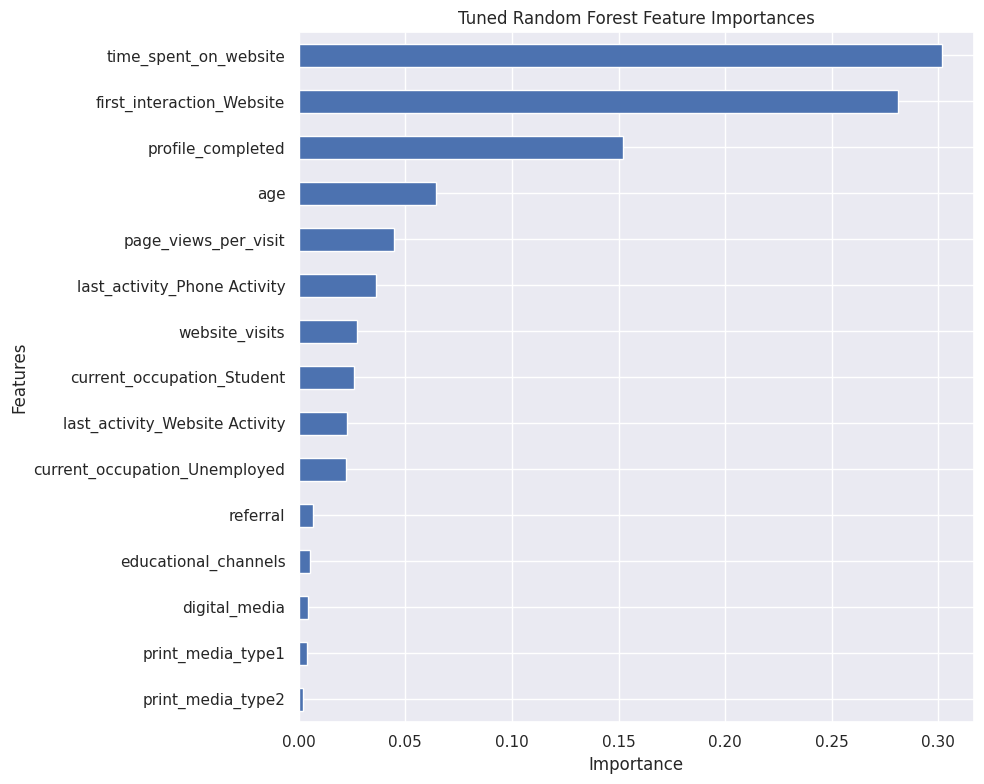

In [ ]:
# Get feature importances from the tuned Random Forest model
feature_importances_tuned = rf_model_tuned.feature_importances_

# Get the names of the features
features = X_train.columns

# Create a pandas Series of feature importances with feature names as index
feature_importance_series_tuned = pd.Series(feature_importances_tuned, index=features)

# Sort feature importances in descending order
sorted_feature_importances_tuned = feature_importance_series_tuned.sort_values(ascending=False)

# Display the sorted feature importances
print("Tuned Random Forest Feature Importances:")
display(sorted_feature_importances_tuned)

# Optionally, visualize the feature importances as a horizontal bar plot
plt.figure(figsize=(10, 8)) # Increased figure size for better readability
sorted_feature_importances_tuned.plot(kind='barh') # Changed to 'barh' for horizontal plot
plt.title('Tuned Random Forest Feature Importances')
plt.xlabel('Importance') # Swapped labels for horizontal plot
plt.ylabel('Features') # Swapped labels for horizontal plot
plt.gca().invert_yaxis() # Invert y-axis to have most important feature at the top
plt.tight_layout()
plt.show()

### Insights and Recommendations

Based on the exploratory data analysis, the statistical tests, and the machine learning models (Decision Tree and Random Forest, particularly the tuned Random Forest model), here are the key factors driving lead conversion and recommendations for ExtraaLearn:

**Key Factors Driving Lead Conversion:**

The analysis consistently highlights several crucial factors that strongly influence a lead's likelihood of converting:

1.  **Website Engagement is the Most Critical Factor:** Features related to how leads interact with the website are the most significant predictors of conversion (supported by EDA visuals, statistical tests for time spent, and high feature importances):
    *   **Time Spent on Website:** Leads who spend significantly more time on the website are far more likely to convert (highest feature importance). This is a powerful indicator of interest and engagement.
    *   **First Interaction Channel:** Leads whose initial interaction is through the Website have a notably higher conversion rate compared to those using the Mobile App (supported by EDA and statistical tests).
    *   **Page Views Per Visit:** A higher average number of pages viewed during website visits is also strongly associated with increased conversion likelihood (supported by EDA and feature importance).

2.  **Profile Completion is Highly Indicative:** The extent to which a lead completes their profile is a very important factor (supported by EDA and high feature importance). High profile completion suggests a higher level of commitment and seriousness from the lead.

3.  **Current Occupation:** Professionals show a statistically significant higher conversion rate compared to students and unemployed individuals (supported by EDA and statistical tests).

4.  **Last Activity:** Specific last interactions matter, with Website Activity and Email Activity showing higher conversion rates than Phone Activity (supported by EDA and statistical tests).

5.  **Referrals:** Although a small volume channel, leads from referrals have a statistically significant higher conversion rate compared to non-referrals (supported by EDA and statistical tests).

Other factors like Print Media Type 1, Print Media Type 2, Digital Media, and Educational Channels did not show a statistically significant association with conversion in our tests, and generally had lower feature importances.

**Actionable Insights and Recommendations:**

Based on these key drivers, ExtraaLearn should focus its efforts on the following areas:

1.  **Revolutionize the Website Experience:** Given that website engagement metrics (Time Spent, First Interaction via Website, Page Views) are the top drivers, optimizing the website is paramount.
    *   **Deepen Engagement:** Invest in creating highly engaging and valuable content (program details, testimonials, free resources) that encourages users to spend more time and explore more pages.
    *   **Optimize First Impression:** Ensure the website provides an intuitive, informative, and positive first experience for visitors.
    *   **User Experience (UX) Enhancement:** Continuously improve website navigation, speed, and mobile responsiveness to facilitate longer sessions and more page views.

2.  **Strategically Encourage Profile Completion:** Since profile completion is a strong signal of intent, incentivize leads to provide more information.
    *   **Clearly Articulate Value:** Explain *why* completing the profile is beneficial to the lead (e.g., unlocking personalized content, receiving tailored program recommendations).
    *   **Simplify the Process:** Make the profile completion flow as quick and user-friendly as possible.
    *   **Gamification/Incentives:** Consider small rewards or progress indicators to motivate completion.

3.  **Refine Targeting and Communication Strategies:**
    *   **Prioritize Professionals:** Tailor marketing messages and potentially offer specific programs or benefits that resonate most with working professionals.
    *   **Leverage High-Converting Interaction Channels:** Focus sales and marketing efforts on nurturing leads through channels associated with higher conversion rates, particularly **Website Activity** (e.g., proactive live chat) and **Email Activity** (e.g., personalized follow-up sequences). Analyze and optimize the Phone Activity process if it's a critical part of the sales cycle.
    *   **Boost Referral Programs:** Invest in and promote referral programs to capitalize on this high-converting channel. Evaluate the ROI of lower-performing marketing channels (print, digital, educational channels) and potentially reallocate budget to higher-impact areas.

4.  **Implement a Lead Scoring System using the Model:** Deploy the best-performing predictive model (the tuned Random Forest model or the GridSearchCV model) to score incoming leads.
    *   **Sales Team Prioritization:** Provide sales representatives with lead scores so they can prioritize reaching out to leads with the highest predicted probability of conversion, optimizing their time and effort.
    *   **Automated Nurturing:** Use lead scores to trigger automated, tailored nurturing sequences for different segments of leads (e.g., high score leads get faster, more direct engagement; lower score leads might enter longer-term nurturing paths).

5.  **Establish Continuous Monitoring and Experimentation:**
    *   **Track Key Metrics:** Continuously monitor the performance of the identified key drivers (website time, page views, profile completion rates, channel effectiveness).
    *   **A/B Test Initiatives:** Implement A/B testing for changes made based on these recommendations (e.g., new website layouts, different call-to-actions, revised email content) to measure their impact on engagement and conversion rates.
    *   **Regular Model Retraining:** Periodically retrain the predictive model with new data to ensure it remains accurate and relevant as lead behavior evolves.

By strategically focusing resources and efforts on enhancing website engagement, encouraging profile completion, targeting high-potential segments and channels, and leveraging the predictive power of the model, ExtraaLearn can significantly improve its lead conversion efficiency and drive growth.